In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid') # Style sạch, đẹp cho báo cáo
sns.set_palette("muted")

# Đọc dữ liệu (Đường dẫn tương tự Question 01)
try:
    df = pd.read_csv('../../data/processed/clean_data.csv') # Cập nhật đường dẫn đúng của bạn
except FileNotFoundError:
    df = pd.read_csv('clean_data.csv') # Fallback nếu file ở cùng thư mục

# Kiểm tra nhanh dữ liệu
print(f"Dữ liệu đã load: {df.shape}")
display(df.head(2))

Dữ liệu đã load: (28554, 34)


,price,area,district,ward,has_air_conditioner,has_kitchen,has_fridge,has_wardrobe,has_bed,has_mattress,...,lock_type,wc_type,water_type,area_group,price_per_sqm,amenity_score,location_score,has_private_facilities,security_score,log_price
0,5500000.0,30.0,tân bình,4,True,True,True,True,True,True,...,fingerprint,unknown,unknown,near_center,183333.333333,9,0,0,3,15.520259
1,3500000.0,26.0,tân bình,2,False,False,False,False,False,False,...,unknown,unknown,bottle,near_center,134615.384615,3,1,0,1,15.068274


# 1. Câu hỏi nghiên cứu & Động cơ
## 1.1. Câu hỏi nghiên cứu
**"Giá trị thị trường (Premium Value) của từng loại tiện nghi là bao nhiêu? Cụ thể, việc trang bị thêm các nội thất như Máy lạnh, Tủ lạnh, hay Máy giặt sẽ giúp chủ nhà tăng giá thuê được bao nhiêu VND so với phòng trống?"**

## 1.2. Động cơ & Lợi ích
* **Bài toán ROI (Return on Investment):**
    * Chủ nhà cần biết: "Bỏ 5 triệu mua tủ lạnh thì bao lâu thu hồi vốn qua việc tăng giá phòng?"
    * Người thuê cần biết: "Mình đang trả đắt hơn 500k chỉ vì cái tủ lạnh cũ, liệu tự mua có rẻ hơn không?"
* **Mục tiêu:** Xây dựng bảng "định giá tham khảo" cho từng món đồ nội thất trong bối cảnh thuê nhà tại TP.HCM.

# 2. Phương pháp phân tích
### Quy trình xử lý:
1.  **Lọc biến mục tiêu:** Trích xuất tất cả các cột biến nhị phân (0/1) đại diện cho tiện nghi (ví dụ: `has_air_conditioner`, `has_fridge`...).
2.  **Tính toán chênh lệch (Price Gap Analysis):**
    Với mỗi tiện ích $i$, ta tính chênh lệch giữa trung vị giá của nhóm CÓ và nhóm KHÔNG CÓ:
    $$\Delta P_i = \text{Median}(P | \text{Has}_i=True) - \text{Median}(P | \text{Has}_i=False)$$
    *(Sử dụng Trung vị để loại bỏ nhiễu từ các căn hộ cao cấp ngoại lai)*
3.  **Chuẩn hóa:** Tính % tăng trưởng để dễ so sánh.

In [3]:
# Xác định các cột tiện ích (thường bắt đầu bằng 'has_' hoặc 'is_')
# Bạn cần kiểm tra lại tên cột chính xác trong df của mình
amenity_cols = [col for col in df.columns if col.startswith('has_') or col.startswith('is_')]
# Loại bỏ các cột không phải tiện nghi vật lý nếu cần (ví dụ has_balcony có thể giữ lại)

premium_data = []

for feature in amenity_cols:
    # Chỉ xét khi cả 2 nhóm (Có và Không) đều có dữ liệu
    if df[feature].nunique() == 2:
        # Tính trung vị giá của 2 nhóm
        median_with = df[df[feature] == 1]['price'].median()
        median_without = df[df[feature] == 0]['price'].median()
        
        # Tính chênh lệch
        gap = median_with - median_without
        percent_increase = (gap / median_without) * 100 if median_without > 0 else 0
        
        # Làm sạch tên tiện ích để hiển thị đẹp hơn
        feature_name = feature.replace('has_', '').replace('is_', '').replace('_', ' ').title()
        
        premium_data.append({
            'Tiện ích': feature_name,
            'Giá có tiện ích': median_with,
            'Giá không tiện ích': median_without,
            'Chênh lệch (VND)': gap,
            'Tăng trưởng (%)': percent_increase
        })

# Tạo DataFrame kết quả và sắp xếp giảm dần theo giá trị chênh lệch
df_premium = pd.DataFrame(premium_data).sort_values(by='Chênh lệch (VND)', ascending=False)

print("Bảng định giá giá trị gia tăng của từng tiện nghi:")
display(df_premium)

Bảng định giá giá trị gia tăng của từng tiện nghi:


,Tiện ích,Giá có tiện ích,Giá không tiện ích,Chênh lệch (VND),Tăng trưởng (%)
16,Private Facilities,5000000.0,3800000.0,1200000.0,31.578947
6,Sofa,5000000.0,3800000.0,1200000.0,31.578947
7,Full Furniture,4300000.0,3200000.0,1100000.0,34.375000
15,Balcony,4400000.0,3600000.0,800000.0,22.222222
4,Bed,4200000.0,3700000.0,500000.0,13.513514
9,Window,4000000.0,3600000.0,400000.0,11.111111
2,Fridge,4000000.0,3700000.0,300000.0,8.108108
3,Wardrobe,4000000.0,3700000.0,300000.0,8.108108
5,Mattress,4000000.0,3800000.0,200000.0,5.263158
14,Parking,3800000.0,3800000.0,0.0,0.000000


# 3. Kết quả & Trực quan hóa
Biểu đồ dưới đây xếp hạng các tiện nghi dựa trên "Số tiền người thuê chấp nhận trả thêm" (Premium Price).

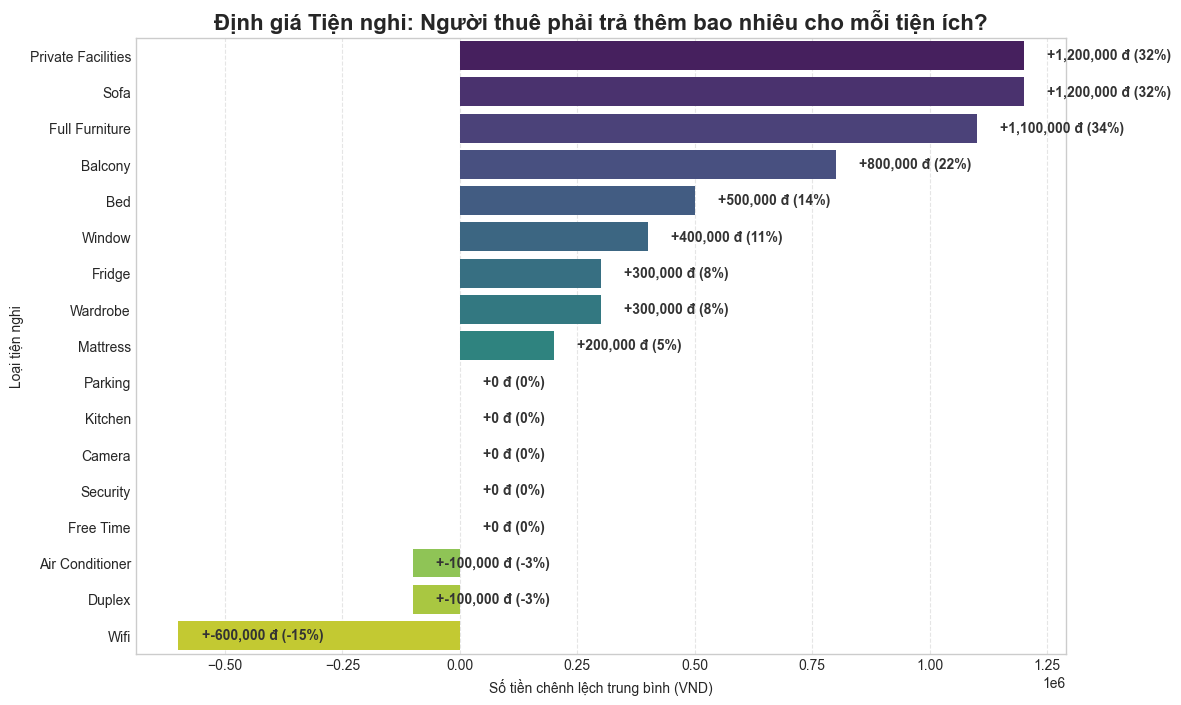

INSIGHT: Tiện ích đắt giá nhất là 'Private Facilities', giúp tăng giá phòng thêm 1,200,000 VND.


In [4]:
plt.figure(figsize=(12, 8))

# Vẽ biểu đồ thanh ngang
barplot = sns.barplot(
    x='Chênh lệch (VND)', 
    y='Tiện ích', 
    data=df_premium, 
    palette='viridis' # Màu sắc chuyển dần đẹp mắt
)

# Thêm nhãn giá trị chi tiết lên từng thanh
for i, p in enumerate(barplot.patches):
    width = p.get_width()
    percent = df_premium.iloc[i]['Tăng trưởng (%)']
    # Viết text bên cạnh thanh
    plt.text(
        width + 50000,  # Vị trí x (dịch sang phải chút cho đỡ dính)
        p.get_y() + p.get_height()/2, 
        f"+{width:,.0f} đ ({percent:.0f}%)", 
        va='center', 
        fontweight='bold', 
        color='#333333'
    )

plt.title('Định giá Tiện nghi: Người thuê phải trả thêm bao nhiêu cho mỗi tiện ích?', fontsize=16, fontweight='bold')
plt.xlabel('Số tiền chênh lệch trung bình (VND)')
plt.ylabel('Loại tiện nghi')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# In ra insight nhanh
top_1 = df_premium.iloc[0]
print(f"INSIGHT: Tiện ích đắt giá nhất là '{top_1['Tiện ích']}', giúp tăng giá phòng thêm {top_1['Chênh lệch (VND)']:,.0f} VND.")

# 4. Kết luận & Hàm ý quản trị
### 4.1. Bảng xếp hạng giá trị (Amenity Valuation)
Dữ liệu chỉ ra 3 nhóm tiện ích rõ rệt:
* **Nhóm "Hạng Sang" (Premium):** Mang lại mức tăng giá cao nhất.
    * **Sofa & Full Furniture:** Giúp tăng giá phòng trung bình từ **1.1 - 1.2 triệu đồng**.
    * **Ban công (Balcony):** Là yếu tố kiến trúc đắt giá, giúp tăng khoảng **800.000đ** so với phòng kín.
* **Nhóm "Tiện nghi cơ bản" (Essential):** Mức tăng giá vừa phải.
    * **Giường, Tủ lạnh, Tủ quần áo:** Mức chênh lệch dao động từ **300.000đ - 500.000đ**. Đây là mức giá hợp lý để sinh viên cân nhắc giữa việc thuê có sẵn hay tự mua sắm.
* **Nhóm "Tiêu chuẩn" (Standard):**
    * **Bếp (Kitchen), Chỗ để xe (Parking), Camera:** Có mức chênh lệch giá xấp xỉ **0 đồng**.
    * $\rightarrow$ **Insight quan trọng:** Thị trường coi đây là các tiện ích mặc định *phải có*. Việc trang bị bếp hay chỗ để xe không giúp bạn tăng giá thuê, nhưng nếu thiếu chúng, bạn sẽ rất khó tìm được khách.

### 4.2. Chiến lược đầu tư (ROI)
* **Chủ nhà:** Đừng kỳ vọng tăng giá phòng chỉ vì có "Chỗ để xe" hay "Wifi". Muốn bứt phá doanh thu, hãy đầu tư vào **Decor (Sofa, Full nội thất)** hoặc cải tạo không gian thoáng (**Ban công/Cửa sổ**).
* **Người thuê:** Nếu muốn tiết kiệm tối đa, hãy tìm các phòng có **Bếp và Chỗ xe** (vì chúng miễn phí) nhưng **Không có nội thất** (Unfurnished). Bạn có thể tiết kiệm được hơn 1 triệu đồng/tháng và tự trang bị đồ đạc cá nhân.